# 02 - Feature engineering for stock data

Read the Parquet output from Task 1 and create features without using future observations.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

cwd = Path.cwd().resolve()
project_root = cwd.parent if cwd.name == 'notebooks' else cwd
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src import config
from src.data_loader import load_table, save_table

## 1. Load and validate the Task 1 output

In [2]:
required_columns = ['ticker', 'date', 'open', 'high', 'low', 'close', 'volume']
stock = load_table(config.STOCK_CLEANED_FILE)
missing_columns = set(required_columns) - set(stock.columns)
if missing_columns:
    raise ValueError(f'Missing Task 1 columns: {sorted(missing_columns)}')

stock = stock.copy()
stock['ticker'] = stock['ticker'].astype('string').str.strip().str.upper()
stock['date'] = pd.to_datetime(stock['date'], errors='raise').dt.normalize()
stock = stock.sort_values(['ticker', 'date']).reset_index(drop=True)

assert not stock[required_columns].isna().any().any(), 'Task 1 output contains missing required values'
assert stock.duplicated(['ticker', 'date']).sum() == 0, 'Duplicate ticker-date rows'
assert stock['ticker'].nunique() == 14, 'Expected 14 stock tickers'

print('Input:', config.STOCK_CLEANED_FILE)
print('Shape:', stock.shape)
print('Tickers:', stock['ticker'].nunique())
display(stock.head())

Input: D:\KLTN\stock_anomaly_detection\data\interim\stock_clean.parquet
Shape: (4690, 8)
Tickers: 14


,ticker,date,open,high,low,close,volume,crawl_timestamp
0,ANV,2025-05-05,14.76,14.81,14.76,14.81,426000,2026-09-04 09:15:08.321000+00:00
1,ANV,2025-05-06,13.99,15.20,13.79,15.20,3802000,2026-09-04 09:15:08.321000+00:00
2,ANV,2025-05-07,15.10,15.30,14.76,15.25,686800,2026-09-04 09:15:08.321000+00:00
3,ANV,2025-05-08,15.25,15.25,14.76,15.10,1323000,2026-09-04 09:15:08.321000+00:00
4,ANV,2025-05-09,15.00,15.00,14.09,14.62,1977000,2026-09-04 09:15:08.321000+00:00


## 2. Create features

Rolling baselines use `shift(1)`, so the current session is not included in its own baseline.

In [3]:
window = 20
grouped = stock.groupby('ticker', sort=False)

stock['return'] = grouped['close'].pct_change(fill_method=None)
stock['abs_return'] = stock['return'].abs()
stock['intraday_range'] = (stock['high'] - stock['low']) / stock['open']
stock['volume_mean_20'] = grouped['volume'].transform(
    lambda values: values.shift(1).rolling(window, min_periods=window).mean()
)
stock['volume_std_20'] = grouped['volume'].transform(
    lambda values: values.shift(1).rolling(window, min_periods=window).std()
)
stock['relative_volume'] = stock['volume'] / stock['volume_mean_20']
stock['volume_z_20'] = (stock['volume'] - stock['volume_mean_20']) / stock['volume_std_20']
stock['volatility_20'] = grouped['return'].transform(
    lambda values: values.shift(1).rolling(window, min_periods=window).std()
)

## 3. Validate feature output

In [4]:
feature_columns = ['return', 'abs_return', 'intraday_range', 'relative_volume', 'volume_z_20', 'volatility_20']
rows_per_ticker = stock.groupby('ticker').cumcount()
warmup_masks = {
    'return': rows_per_ticker < 1,
    'abs_return': rows_per_ticker < 1,
    'relative_volume': rows_per_ticker < window,
    'volume_z_20': rows_per_ticker < window,
    'volatility_20': rows_per_ticker <= window,
}

assert stock.duplicated(['ticker', 'date']).sum() == 0
assert np.isfinite(stock['intraday_range']).all()
assert stock['intraday_range'].ge(0).all()
assert (stock['volume_std_20'].dropna() > 0).all(), 'Zero rolling volume deviation'
for column, warmup_mask in warmup_masks.items():
    assert stock.loc[~warmup_mask, column].notna().all(), f'{column} has unexpected missing values'
    assert np.isfinite(stock.loc[~warmup_mask, column]).all(), f'{column} has infinite values'

display(stock[feature_columns].isna().sum().rename('missing_rows').to_frame())
display(stock[feature_columns].describe())
print('All feature quality checks passed.')

,missing_rows
return,14
abs_return,14
intraday_range,0
relative_volume,280
volume_z_20,280
volatility_20,294


,return,abs_return,intraday_range,relative_volume,volume_z_20,volatility_20
count,4676.000000,4676.000000,4690.000000,4410.000000,4410.000000,4396.000000
mean,0.000465,0.012859,0.023992,1.030689,0.056759,0.017351
std,0.019334,0.014444,0.016008,0.825753,1.622551,0.008797
min,-0.069859,0.000000,0.000000,0.016038,-3.426162,0.001878
25%,-0.008441,0.002794,0.012728,0.604168,-0.775752,0.009902
50%,0.000000,0.008288,0.019819,0.848385,-0.318023,0.016910
75%,0.008131,0.017213,0.030666,1.208329,0.430229,0.023172
max,0.070399,0.070399,0.152295,25.406162,46.404083,0.058417


All feature quality checks passed.


## 4. Inspect MWG

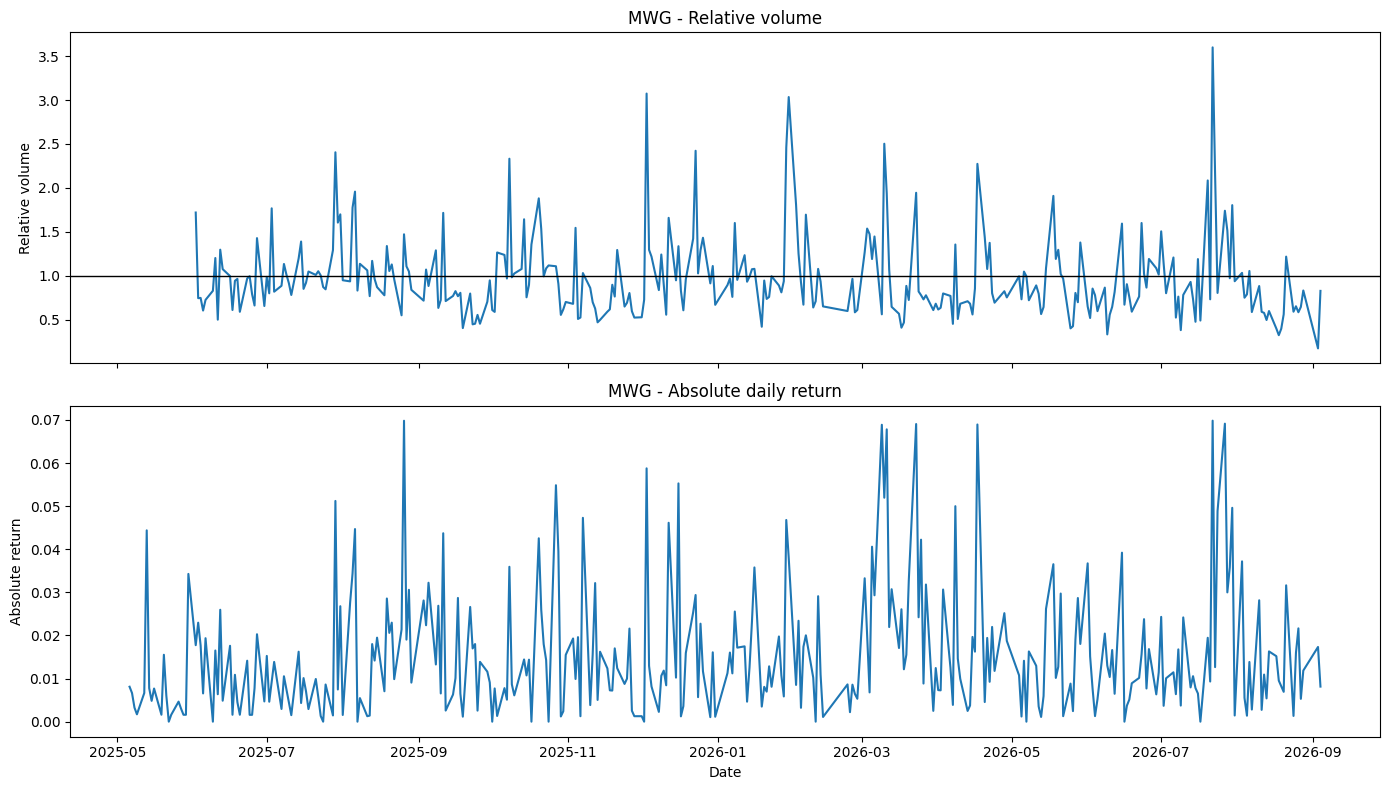

In [5]:
mwg = stock.loc[stock['ticker'].eq('MWG')].copy()
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(mwg['date'], mwg['relative_volume'])
axes[0].axhline(1, color='black', linewidth=1)
axes[0].set_ylabel('Relative volume')
axes[0].set_title('MWG - Relative volume')
axes[1].plot(mwg['date'], mwg['abs_return'])
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Absolute return')
axes[1].set_title('MWG - Absolute daily return')
plt.tight_layout()
plt.show()

## 5. Save the Parquet output

In [6]:
output_columns = [
    'ticker', 'date', 'open', 'high', 'low', 'close', 'volume',
    'return', 'abs_return', 'intraday_range', 'volume_mean_20',
    'volume_std_20', 'relative_volume', 'volume_z_20', 'volatility_20',
]
stock_features = stock[output_columns].copy()
save_table(stock_features, config.STOCK_FEATURES_FILE)

check = load_table(config.STOCK_FEATURES_FILE)
pd.testing.assert_frame_equal(check, stock_features)
assert config.STOCK_FEATURES_FILE.suffix == '.parquet'

print('Saved:', config.STOCK_FEATURES_FILE)
print('Output shape:', check.shape)
display(check.head())

Saved: D:\KLTN\stock_anomaly_detection\data\processed\stock_features.parquet
Output shape: (4690, 15)


,ticker,date,open,high,low,close,volume,return,abs_return,intraday_range,volume_mean_20,volume_std_20,relative_volume,volume_z_20,volatility_20
0,ANV,2025-05-05,14.76,14.81,14.76,14.81,426000,NaN,NaN,0.003388,NaN,NaN,NaN,NaN,NaN
1,ANV,2025-05-06,13.99,15.20,13.79,15.20,3802000,0.026334,0.026334,0.100786,NaN,NaN,NaN,NaN,NaN
2,ANV,2025-05-07,15.10,15.30,14.76,15.25,686800,0.003289,0.003289,0.035762,NaN,NaN,NaN,NaN,NaN
3,ANV,2025-05-08,15.25,15.25,14.76,15.10,1323000,-0.009836,0.009836,0.032131,NaN,NaN,NaN,NaN,NaN
4,ANV,2025-05-09,15.00,15.00,14.09,14.62,1977000,-0.031788,0.031788,0.060667,NaN,NaN,NaN,NaN,NaN
